# Doom vs Animal Crossing Meme Classifier

Reddit Meme 이미지를 Doom(0) vs Animal Crossing(1) 서브레딧으로 분류하는 CNN 모델입니다.

- **평가 지표**: Balanced Accuracy
- **규칙**: Pre-trained model 사용 금지, 처음부터 CNN 직접 구축
- **이미지 크기 통일**: `image_dataset_from_directory` 활용

In [44]:
# 필요한 라이브러리 설치
!pip install -q tensorflow pandas numpy scikit-learn matplotlib seaborn

zsh:1: command not found: pip


In [45]:
import sys
!{sys.executable} -m pip install -q tensorflow pandas numpy scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [46]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─────────────────────────────────────────────────────────────
#  여기만 수정: train-label.csv, test-label.csv, img/ 폴더가
#  있는 디렉토리의 절대경로를 입력하세요
# ─────────────────────────────────────────────────────────────
BASE_DIR = Path('.').resolve()          # 현재 폴더 절대경로로 고정
                                        # 예: Path('/Users/yourname/Downloads/knu_ml')

IMG_DIR  = (BASE_DIR / 'img').resolve()
WORK_DIR = (BASE_DIR / 'working').resolve()

TRAIN_DIR  = WORK_DIR / 'dataset' / 'train'
VAL_DIR    = WORK_DIR / 'dataset' / 'val'
TEST_DIR   = WORK_DIR / 'dataset' / 'test'
MODEL_PATH = WORK_DIR / 'best_model.keras'
WORK_DIR.mkdir(parents=True, exist_ok=True)

# 하이퍼파라미터
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
EPOCHS      = 60
VAL_SPLIT   = 0.15
LR_INIT     = 1e-3
NUM_CLASSES = 2

print(f"BASE_DIR : {BASE_DIR}")
print(f"IMG_DIR  : {IMG_DIR}  (exists={IMG_DIR.exists()})")
print(f"WORK_DIR : {WORK_DIR}")
print(f"TensorFlow: {tf.__version__}, GPU: {len(tf.config.list_physical_devices('GPU'))}")

BASE_DIR : /Users/dayana/git repo/machine-learning-class/lab5
IMG_DIR  : /Users/dayana/git repo/machine-learning-class/lab5/img  (exists=True)
WORK_DIR : /Users/dayana/git repo/machine-learning-class/lab5/working
TensorFlow: 2.21.0, GPU: 0


## 1. 경로 및 하이퍼파라미터 설정

In [47]:
TRAIN_LABEL  = pd.read_csv(BASE_DIR / 'train-label.csv', index_col='id')
TEST_LABEL   = pd.read_csv(BASE_DIR / 'test-label.csv',  index_col='id')
SUB_TEMPLATE = pd.read_csv(BASE_DIR / 'submission.csv')

print(f"Train: {len(TRAIN_LABEL)}, Test: {len(TEST_LABEL)}")
print("Label dist:\n", TRAIN_LABEL['label'].value_counts().sort_index())

# ── img/ 폴더 전체 재귀 탐색 → 파일명:절대경로 매핑 ──────────
img_files = (list(IMG_DIR.rglob('*.jpg'))
           + list(IMG_DIR.rglob('*.jpeg'))
           + list(IMG_DIR.rglob('*.png')))
file_map = {f.name: str(f.resolve()) for f in img_files}   # ← 절대경로 강제

print(f"\n발견된 이미지: {len(img_files)}개, 매핑: {len(file_map)}개")

# 매핑 검증 (❌이 뜨면 IMG_DIR 경로를 확인)
for fname in TRAIN_LABEL['file'].head(5):
    print(f"  {'✅' if fname in file_map else '❌'} {fname}")


def build_directory_structure(df, dest_dir, is_test=False):
    """
    shutil.copy2로 실제 파일 복사 (symlink 없음).
    모든 경로는 절대경로 사용.
    """
    dest_dir = Path(dest_dir).resolve()        # ← 반드시 절대경로
    if dest_dir.exists():
        shutil.rmtree(dest_dir)

    missing = 0
    if is_test:
        (dest_dir / 'images').mkdir(parents=True)
        for img_id, row in df.iterrows():
            src = file_map.get(row['file'])
            if src:
                shutil.copy2(src, dest_dir / 'images' / f"{img_id}_{row['file']}")
            else:
                missing += 1
    else:
        for cls in ['0', '1']:
            (dest_dir / cls).mkdir(parents=True)
        for img_id, row in df.iterrows():
            src = file_map.get(row['file'])
            if src:
                dst = dest_dir / str(row['label']) / f"{img_id}_{row['file']}"
                shutil.copy2(src, dst)
            else:
                missing += 1

    total = len(df)
    print(f"  → {dest_dir.name}: {total - missing}/{total} 복사 완료"
          + (f", ⚠️ {missing}개 누락" if missing else ""))
    return dest_dir


# Train / Val stratified split
train_split, val_split = train_test_split(
    TRAIN_LABEL.reset_index(),
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=TRAIN_LABEL['label']
)
train_split = train_split.set_index('id')
val_split   = val_split.set_index('id')

print(f"\nTrain: {len(train_split)}, Val: {len(val_split)}")
print("파일 복사 중... (수십 초 소요)")

build_directory_structure(train_split, TRAIN_DIR)
build_directory_structure(val_split,   VAL_DIR)
build_directory_structure(TEST_LABEL,  TEST_DIR, is_test=True)

# ── 복사 결과 검증 ─────────────────────────────────────────
for split_name, split_dir in [('train', TRAIN_DIR), ('val', VAL_DIR)]:
    for cls in ['0', '1']:
        n = len(list((split_dir / cls).iterdir()))
        print(f"  {split_name}/class{cls}: {n}개")
n_test = len(list((TEST_DIR / 'images').iterdir()))
print(f"  test/images: {n_test}개")

print("\n✅ 디렉토리 구조 생성 완료")

Train: 1385, Test: 1386
Label dist:
 label
0    707
1    678
Name: count, dtype: int64

발견된 이미지: 2771개, 매핑: 2771개
  ✅ 001bd5563b4511f0b16c00155d672fff.png
  ✅ d13cde743b4411f0b16c00155d672fff.jpg
  ✅ 96f4bf1a3b4511f0b16c00155d672fff.jpg
  ✅ 43f18faa3b4511f0b16c00155d672fff.jpg
  ✅ bf0df3a03b4411f0b16c00155d672fff.png

Train: 1177, Val: 208
파일 복사 중... (수십 초 소요)
  → train: 1177/1177 복사 완료
  → val: 208/208 복사 완료
  → test: 1386/1386 복사 완료
  train/class0: 601개
  train/class1: 576개
  val/class0: 106개
  val/class1: 102개
  test/images: 1386개

✅ 디렉토리 구조 생성 완료


## 2. 데이터 로드 및 디렉토리 구조 생성

In [48]:
# CSV 파일 로드
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
sub_df   = pd.read_csv(SUBMISSION_CSV)

print(f"Train samples: {len(train_df)}")
print(f"Test  samples: {len(test_df)}")
print(f"\nTrain label distribution:")
print(train_df['label'].value_counts())
print(f"\nLabel: 0 = Doom, 1 = Animal Crossing")

Train samples: 1385
Test  samples: 1386

Train label distribution:
label
0    707
1    678
Name: count, dtype: int64

Label: 0 = Doom, 1 = Animal Crossing


In [49]:
# img/ 폴더에서 모든 이미지 파일 탐색 후 파일명 → 경로 매핑
img_files = list(Path(IMG_DIR).rglob('*.jpg')) + \
            list(Path(IMG_DIR).rglob('*.png')) + \
            list(Path(IMG_DIR).rglob('*.jpeg'))
file_map = {f.name: str(f) for f in img_files}

print(f"발견된 이미지 파일 수: {len(img_files)}")

# 매핑 검증
sample_files = TRAIN_LABEL['file'].head(5).tolist()
for fname in sample_files:
    status = '✅' if fname in file_map else '❌ 없음 — IMG_DIR 경로를 확인하세요'
    print(f"  {fname}: {status}")


def build_directory_structure(df, dest_dir, is_test=False):
    """
    image_dataset_from_directory 용 폴더 구조 생성.
    symlink 없이 shutil.copy2로 실제 파일을 복사합니다.
    - train/val : dest_dir/0/ 과 dest_dir/1/ 로 분류
    - test       : dest_dir/images/ 에 {id}_{fname} 으로 저장
    """
    dest_dir = Path(dest_dir)
    if dest_dir.exists():
        shutil.rmtree(dest_dir)

    missing = 0
    if is_test:
        (dest_dir / 'images').mkdir(parents=True)
        for img_id, row in df.iterrows():
            fname = row['file']
            src   = file_map.get(fname)
            if src:
                shutil.copy2(src, dest_dir / 'images' / f"{img_id}_{fname}")
            else:
                missing += 1
    else:
        for cls in ['0', '1']:
            (dest_dir / cls).mkdir(parents=True)
        for img_id, row in df.iterrows():
            fname = row['file']
            label = str(row['label'])
            src   = file_map.get(fname)
            if src:
                shutil.copy2(src, dest_dir / label / f"{img_id}_{fname}")
            else:
                missing += 1

    if missing:
        print(f"  ⚠️  {missing}개 파일을 file_map에서 찾지 못했습니다.")
    return dest_dir


# Train / Val stratified split
train_split, val_split = train_test_split(
    TRAIN_LABEL.reset_index(),   # id 컬럼 복원
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=TRAIN_LABEL['label']
)
train_split = train_split.set_index('id')
val_split   = val_split.set_index('id')

print(f"\nTrain: {len(train_split)}, Val: {len(val_split)}")
print("디렉토리 복사 중... (이미지 수에 따라 수십 초 소요)")

build_directory_structure(train_split, TRAIN_DIR)
build_directory_structure(val_split,   VAL_DIR)
build_directory_structure(TEST_LABEL,  TEST_DIR, is_test=True)

print("✅ 디렉토리 구조 생성 완료")

발견된 이미지 파일 수: 2771
  001bd5563b4511f0b16c00155d672fff.png: ✅
  d13cde743b4411f0b16c00155d672fff.jpg: ✅
  96f4bf1a3b4511f0b16c00155d672fff.jpg: ✅
  43f18faa3b4511f0b16c00155d672fff.jpg: ✅
  bf0df3a03b4411f0b16c00155d672fff.png: ✅

Train: 1177, Val: 208
디렉토리 복사 중... (이미지 수에 따라 수십 초 소요)
✅ 디렉토리 구조 생성 완료


In [50]:
def build_directory_structure(df, dest_dir, is_test=False):
    """
    image_dataset_from_directory 사용을 위해
    클래스별 폴더에 이미지를 심볼릭 링크 또는 복사로 구성합니다.
    test의 경우 단일 폴더('images')에 모두 넣습니다.
    """
    dest_dir = Path(dest_dir)
    if dest_dir.exists():
        shutil.rmtree(dest_dir)
    
    if is_test:
        (dest_dir / 'images').mkdir(parents=True)
        for _, row in df.iterrows():
            fname = row['file']
            src = file_map.get(fname)
            if src:
                dst = dest_dir / 'images' / f"{row['id']}_{fname}"
                if not dst.exists():
                    os.symlink(src, dst)
    else:
        for cls in ['0', '1']:
            (dest_dir / cls).mkdir(parents=True)
        for _, row in df.iterrows():
            fname = row['file']
            label = str(row['label'])
            src = file_map.get(fname)
            if src:
                dst = dest_dir / label / f"{row['id']}_{fname}"
                if not dst.exists():
                    os.symlink(src, dst)
    
    return dest_dir


# Train / Validation 분할
train_split, val_split = train_test_split(
    train_df, test_size=VAL_SPLIT, random_state=SEED, stratify=train_df['label']
)
print(f"Train: {len(train_split)}, Val: {len(val_split)}")

# 디렉토리 구조 생성
build_directory_structure(train_split, TRAIN_DIR)
build_directory_structure(val_split,   VAL_DIR)
build_directory_structure(test_df,     TEST_DIR, is_test=True)

print("디렉토리 구조 생성 완료")

Train: 1177, Val: 208
디렉토리 구조 생성 완료


## 3. 데이터 파이프라인 구성

In [51]:
# ── 학습 데이터셋 ──────────────────────────────
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    class_names=['0', '1'],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

# ── 검증 데이터셋 ──────────────────────────────
val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='int',
    class_names=['0', '1'],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
)

# ── 테스트 데이터셋 (파일명에서 id 추출) ──────────
test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# 테스트 이미지 순서대로 ID 추출 (파일명: {id}_{original_fname})
test_file_paths = test_ds.file_paths
test_ids = [int(Path(p).stem.split('_')[0]) for p in test_file_paths]
print(f"Test image count: {len(test_ids)}")

Found 1177 files belonging to 2 classes.
Found 208 files belonging to 2 classes.
Found 1386 files.
Test image count: 1386


In [52]:
# ─────────────────────────────────────────────
# 데이터 증강 레이어 (학습 시에만 적용)
# ─────────────────────────────────────────────
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name='data_augmentation')


def preprocess(image, label=None):
    """픽셀 값을 [0, 1]로 정규화"""
    image = tf.cast(image, tf.float32) / 255.0
    if label is not None:
        return image, label
    return image


AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(lambda x: preprocess(x), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print("데이터 파이프라인 준비 완료")

데이터 파이프라인 준비 완료


## 4. CNN 모델 정의 (처음부터 구축)

Pre-trained model 사용 금지 규칙에 따라, **Depthwise Separable Convolution**을 활용한 경량 고성능 CNN을 처음부터 직접 구현합니다.

In [53]:
def residual_block(x, filters, stride=1):
    """잔차 연결(Residual connection)이 있는 블록"""
    shortcut = x
    
    # 메인 경로
    x = layers.SeparableConv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.SeparableConv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    
    # Shortcut 경로 (차원 맞추기)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def build_model(input_shape=(128, 128, 3), num_classes=2):
    """
    Residual + Depthwise Separable Convolution 기반 Custom CNN.
    Pre-trained 모델 일절 미사용 — 가중치는 처음부터 학습.
    """
    inputs = keras.Input(shape=input_shape)
    
    # ── Stem ──────────────────────────────────
    x = layers.Conv2D(32, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # ── Stage 1 ───────────────────────────────
    x = residual_block(x, 64)
    x = residual_block(x, 64)
    
    # ── Stage 2 ───────────────────────────────
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)
    x = residual_block(x, 128)
    
    # ── Stage 3 ───────────────────────────────
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)
    x = residual_block(x, 256)
    x = residual_block(x, 256)
    
    # ── Stage 4 ───────────────────────────────
    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512)
    
    # ── Head ──────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return keras.Model(inputs, outputs, name='custom_resnet')


model = build_model(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
model.summary()

Model: "custom_resnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 64, 64,    │        864 │ input_layer_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │     18,432 │ activation_96[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_88 │ (None, 64, 64,    │      4,672 │ activation_97[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_89 │ (None, 64, 64,    │      4,672 │ activation_98[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_44 (Add)        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation_97[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_99       │ (None, 64, 64,    │          0 │ add_44[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_90 │ (None, 64, 64,    │      4,672 │ activation_99[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_100      │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 1,905,186 (7.27 MB)

 Trainable params: 1,892,962 (7.22 MB)

 Non-trainable params: 12,224 (47.75 KB)

## 5. 모델 컴파일 및 학습

In [54]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_INIT),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

callbacks = [
    # 검증 손실 기준 최적 모델 저장
    ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1,
    ),
    # 개선 없으면 학습률 감소
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
    # 조기 종료
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/60


W0000 00:00:1779941695.973021  136628 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779941696.381343  136635 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


 2/37 ━━━━━━━━━━━━━━━━━━━━ 24s 714ms/step - accuracy: 0.3906 - loss: 0.9366

W0000 00:00:1779941697.508981  136630 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779941697.544995  136635 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779941697.945179  136635 png_io.cc:96] PNG warning: iCCP: extra compressed data
W0000 00:00:1779941698.103494  136629 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


 3/37 ━━━━━━━━━━━━━━━━━━━━ 24s 730ms/step - accuracy: 0.4028 - loss: 0.9730

W0000 00:00:1779941698.658130  136634 png_io.cc:96] PNG warning: iCCP: extra compressed data
W0000 00:00:1779941698.866428  136628 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.4721 - loss: 1.0868

W0000 00:00:1779941712.835437  137058 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779941713.002161  137053 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile



Epoch 1: val_accuracy improved from None to 0.50962, saving model to /Users/dayana/git repo/machine-learning-class/lab5/working/best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 468ms/step - accuracy: 0.4902 - loss: 1.0679 - val_accuracy: 0.5096 - val_loss: 0.7272 - learning_rate: 0.0010
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.5250 - loss: 0.8584
Epoch 2: val_accuracy did not improve from 0.50962
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 418ms/step - accuracy: 0.5072 - loss: 0.8631 - val_accuracy: 0.5096 - val_loss: 0.7271 - learning_rate: 0.0010
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.5013 - loss: 0.8135
Epoch 3: val_accuracy did not improve from 0.50962
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 425ms/step - accuracy: 0.4970 - loss: 0.7964 - val_accuracy: 0.4904 - val_loss: 0.7268 - learning_rate: 0.0010
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.4979 - loss: 0.7627
Epoch 4: val_accuracy did not improve from 0.50962
37/37 ━━━━━━━━━━━

## 6. 학습 결과 시각화

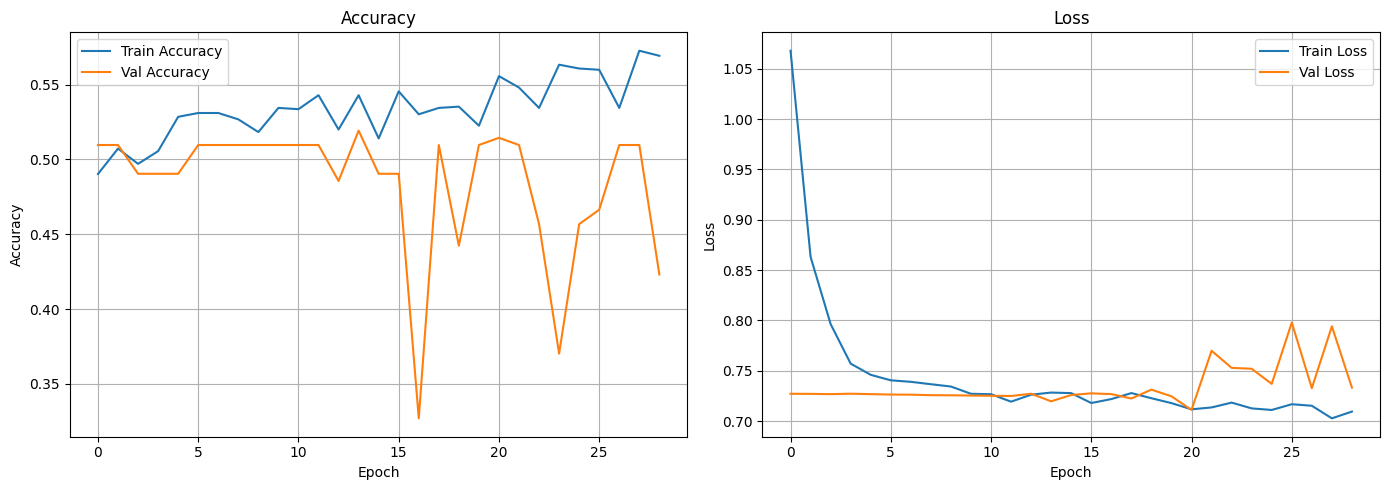

최고 검증 정확도: 0.5192


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정확도 곡선
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# 손실 곡선
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(str(WORK_DIR / 'training_curves.png'), dpi=100)
plt.show()
print(f"최고 검증 정확도: {max(history.history['val_accuracy']):.4f}")

## 7. 검증 세트 Balanced Accuracy 평가

Validation Balanced Accuracy: 0.5124

                    precision    recall  f1-score   support

           Doom(0)       0.52      0.87      0.65       106
Animal Crossing(1)       0.53      0.16      0.24       102

          accuracy                           0.52       208
         macro avg       0.53      0.51      0.45       208
      weighted avg       0.52      0.52      0.45       208



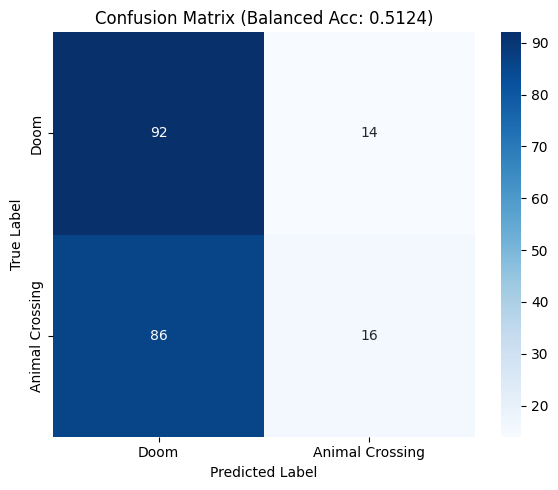

In [56]:
# 최적 모델 로드
best_model = keras.models.load_model(str(MODEL_PATH))

# 검증 세트 예측
val_preds_prob = best_model.predict(val_ds, verbose=0)
val_preds = np.argmax(val_preds_prob, axis=1)

# 실제 레이블 수집
val_true = np.concatenate([y.numpy() for _, y in val_ds])

# Balanced Accuracy 계산
ba_score = balanced_accuracy_score(val_true, val_preds)
print(f"Validation Balanced Accuracy: {ba_score:.4f}")
print()
print(classification_report(val_true, val_preds, target_names=['Doom(0)', 'Animal Crossing(1)']))

# 혼동 행렬
cm = confusion_matrix(val_true, val_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Doom', 'Animal Crossing'],
            yticklabels=['Doom', 'Animal Crossing'])
plt.title(f'Confusion Matrix (Balanced Acc: {ba_score:.4f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(str(WORK_DIR / 'confusion_matrix.png'), dpi=100)
plt.show()

## 8. 테스트 세트 예측 및 제출 파일 생성

In [57]:
# 테스트 세트 예측 (TTA: Test Time Augmentation — 여러 번 예측 후 평균)
TTA_STEPS = 5

tta_aug = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='tta_augmentation')

@tf.function
def tta_predict_batch(images):
    """단일 배치에 대해 TTA 적용 후 평균 예측"""
    preds = []
    # 원본 예측
    preds.append(best_model(images, training=False))
    # 증강 예측
    for _ in range(TTA_STEPS - 1):
        aug_images = tta_aug(images, training=True)
        preds.append(best_model(aug_images, training=False))
    return tf.reduce_mean(tf.stack(preds), axis=0)


# TTA 예측 수행
all_preds_prob = []
for batch in test_ds:
    batch_prob = tta_predict_batch(batch).numpy()
    all_preds_prob.append(batch_prob)

all_preds_prob = np.concatenate(all_preds_prob, axis=0)
all_preds      = np.argmax(all_preds_prob, axis=1)

print(f"예측 완료. 총 {len(all_preds)}개")
print(f"예측 분포 - Doom(0): {(all_preds==0).sum()}, Animal Crossing(1): {(all_preds==1).sum()}")

W0000 00:00:1779942229.065302  146230 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779942229.199651  146227 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779942229.854089  146231 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779942230.304978  146227 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779942241.896559  146225 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779942241.896581  146225 png_io.cc:96] PNG warning: iCCP: cHRM chunk does not match sRGB


예측 완료. 총 1386개
예측 분포 - Doom(0): 1213, Animal Crossing(1): 173


In [58]:
# 제출 파일 생성
# test_ids 순서와 예측 순서를 일치시킴
pred_map = dict(zip(test_ids, all_preds))

# submission.csv의 id 순서에 맞게 예측값 할당
sub_df = pd.read_csv(SUBMISSION_CSV)
sub_df['label'] = sub_df['id'].map(pred_map)

# 혹시 매핑되지 않은 ID가 있을 경우 확인
missing = sub_df['label'].isna().sum()
if missing > 0:
    print(f"WARNING: {missing}개 ID에 예측값 없음 — 0으로 채움")
    sub_df['label'] = sub_df['label'].fillna(0)

sub_df['label'] = sub_df['label'].astype(int)

# 저장
output_path = WORK_DIR / 'submission10.csv'
sub_df.to_csv(output_path, index=False)

print(f"제출 파일 저장 완료: {output_path}")
print(f"\n최종 제출 파일 미리보기:")
print(sub_df.head(10))
print(f"\nLabel 분포:")
print(sub_df['label'].value_counts())

제출 파일 저장 완료: /Users/dayana/git repo/machine-learning-class/lab5/working/submission10.csv

최종 제출 파일 미리보기:
     id  label
0  2078      0
1  2079      1
2  2080      0
3  2081      0
4  2082      0
5  2083      1
6  2084      0
7  2085      0
8  2086      1
9  2087      0

Label 분포:
label
0    1213
1     173
Name: count, dtype: int64


## 9. 제출 파일 형식 검증

In [59]:
# 제출 파일 유효성 검사
result_df = pd.read_csv(output_path)

assert list(result_df.columns) == ['id', 'label'], "컬럼명 오류"
assert result_df['label'].isin([0, 1]).all(),       "레이블 값은 0 또는 1이어야 함"
assert len(result_df) == len(sub_df),               "행 수 불일치"

print("✅ 제출 파일 유효성 검사 통과")
print(f"   - 행 수: {len(result_df)}")
print(f"   - 컬럼: {list(result_df.columns)}")
print(f"   - 레이블 고유값: {sorted(result_df['label'].unique())}")
print(f"\n제출 준비 완료! '{output_path}' 파일을 Kaggle에 제출하세요.")

✅ 제출 파일 유효성 검사 통과
   - 행 수: 1386
   - 컬럼: ['id', 'label']
   - 레이블 고유값: [np.int64(0), np.int64(1)]

제출 준비 완료! '/Users/dayana/git repo/machine-learning-class/lab5/working/submission10.csv' 파일을 Kaggle에 제출하세요.
